# I.5 — The Galton Board: Order from Chaos

A ball drops through 12 rows of pegs. At each peg: coin flip — bounce left or right.
Where it lands is just the count of right-bounces:

$$\text{slot} = \sum_{i=1}^{12} \text{bounce}_i$$

(That Σ is Module 0.6 — read it as a for-loop.) One ball is pure chance.
A hundred thousand balls are about to obey a law.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # a seeded random generator: same "random" numbers every run

In [2]:
# One ball. rng.integers(0, 2, size=12) = twelve random 0s and 1s (0 = left, 1 = right).
bounces = rng.integers(0, 2, size=12)
print("bounces:", bounces, "-> lands in slot", bounces.sum())

# Three more balls — every path is different:
for _ in range(3):
    b = rng.integers(0, 2, size=12)
    print("bounces:", b, "-> lands in slot", b.sum())

bounces: [0 1 1 0 0 1 0 1 0 0 1 1] -> lands in slot 6
bounces: [1 1 1 1 1 0 1 0 1 0 0 1] -> lands in slot 8
bounces: [1 1 0 1 1 0 0 0 0 1 1 0] -> lands in slot 6
bounces: [1 1 0 1 0 1 1 0 0 1 0 1] -> lands in slot 7


In [3]:
# Now drop 100,000 balls AT ONCE: a 100,000 x 12 grid of bounces, one row per ball.
n_balls, n_rows = 100_000, 12
slots = rng.integers(0, 2, size=(n_balls, n_rows)).sum(axis=1)   # sum each row = each ball's slot
print("first 20 balls landed in slots:", slots[:20])

first 20 balls landed in slots: [6 5 5 7 8 5 9 4 6 6 6 4 5 6 5 6 5 5 5 4]


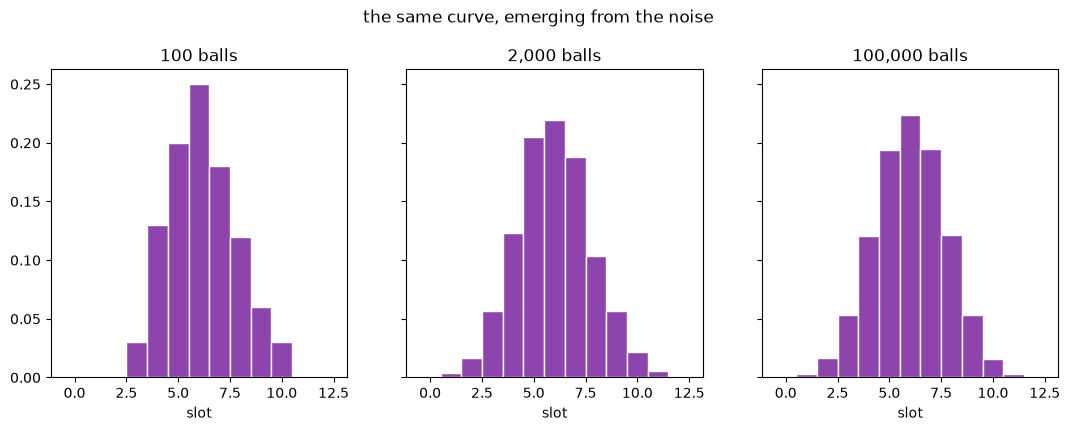

In [4]:
# Watch the shape sharpen as the ball count grows.
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, n in zip(axes, [100, 2_000, 100_000]):
    ax.hist(slots[:n], bins=np.arange(14) - 0.5, density=True,
            color="#8e44ad", edgecolor="white")
    ax.set_title(f"{n:,} balls")
    ax.set_xlabel("slot")
fig.suptitle("the same curve, emerging from the noise", y=1.03)
plt.show()

## The law being enforced

That shape is the **normal distribution** — the bell curve — and its formula was derived with
pen and paper, centuries before computers:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

The **central limit theorem** says: add up enough small independent random nudges — of almost
*any* kind — and their sum always takes this shape. For 12 fair bounces, theory predicts centre
$\mu = 6$ and spread $\sigma = \sqrt{12 \times \tfrac14} = \sqrt{3}$.

Time for the confrontation: your simulated pile of balls vs. a 200-year-old formula.

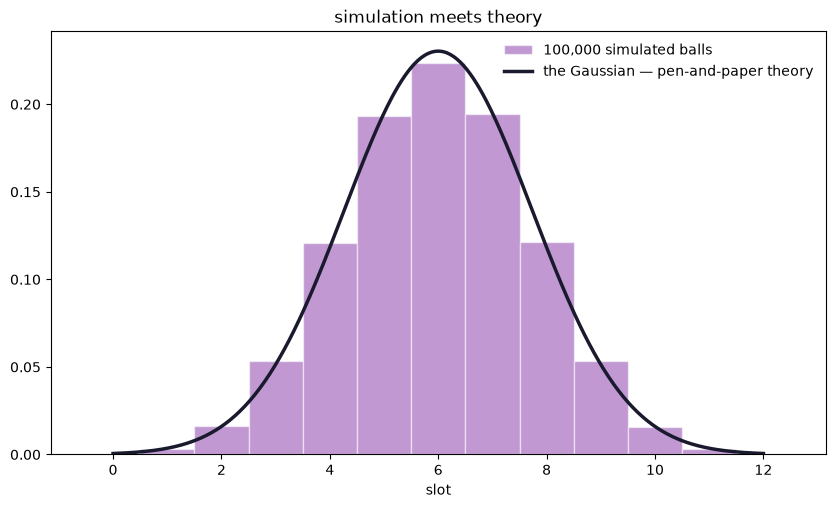

In [5]:
mu = n_rows / 2                      # theory: centre of the pile
sigma = np.sqrt(n_rows / 4)          # theory: its spread

x = np.linspace(0, 12, 400)
bell = np.exp(-((x - mu) ** 2) / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

plt.figure(figsize=(10, 5.5))
plt.hist(slots, bins=np.arange(14) - 0.5, density=True,
         color="#8e44ad", alpha=0.55, edgecolor="white", label="100,000 simulated balls")
plt.plot(x, bell, color="#1a1a2e", linewidth=2.5, label="the Gaussian — pen-and-paper theory")
plt.legend(frameon=False)
plt.xlabel("slot")
plt.title("simulation meets theory")
plt.show()

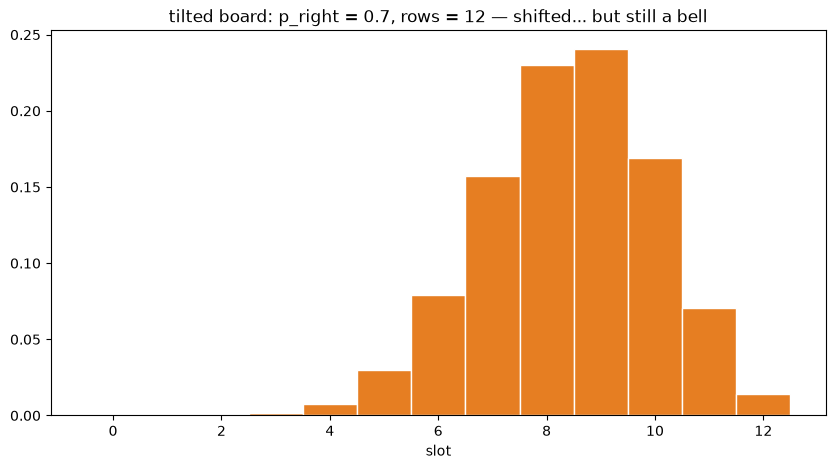

In [6]:
# YOUR TURN — try to ESCAPE the bell curve.
#   1) Tilt the board: p_right = 0.7. (rng.random() < p is a coin with probability p of True.)
#   2) More rows: n_rows = 30, or 50.
#   3) Can you find ANY setting where a bell doesn't appear? (It may shift and stretch — but the shape?)
p_right, n_rows = 0.7, 12

slots = (rng.random((100_000, n_rows)) < p_right).sum(axis=1)   # True counts as 1 when summed

plt.figure(figsize=(10, 5))
plt.hist(slots, bins=np.arange(n_rows + 2) - 0.5, density=True,
         color="#e67e22", edgecolor="white")
plt.xlabel("slot")
plt.title(f"tilted board: p_right = {p_right}, rows = {n_rows} — shifted... but still a bell")
plt.show()

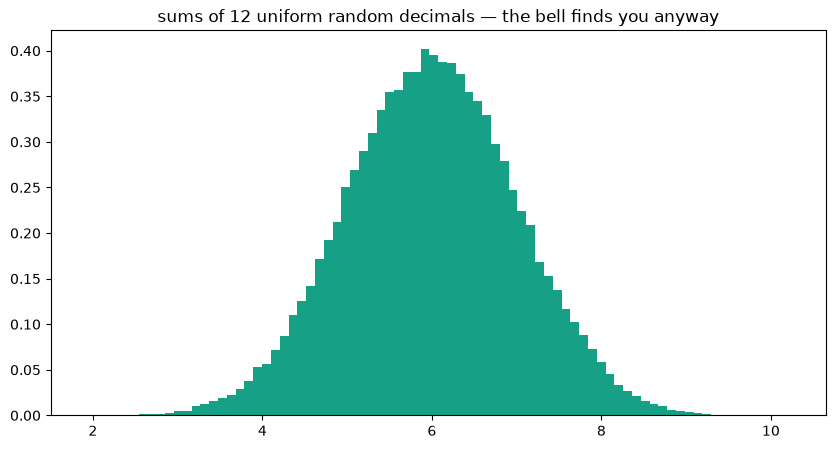

In [7]:
# One more escape attempt — forget pegs entirely. Sum 12 random DECIMALS between 0 and 1.
# No coins, no slots, a totally different kind of randomness...
sums = rng.random((100_000, 12)).sum(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(sums, bins=80, density=True, color="#16a085", edgecolor="none")
plt.title("sums of 12 uniform random decimals — the bell finds you anyway")
plt.show()

## What you just saw

You couldn't escape. Coins, tilted coins, uniform decimals — every sum of many small independent
nudges collapsed into the same silhouette. That's the central limit theorem, and it's *why the
Gaussian rules the universe*: heights, measurement errors, sensor noise, thermal jitter — each is
a sum of countless tiny influences, so each wears the bell.

It's also why diffusion models are built on Gaussian noise. When you noise an image with
thousands of small random nudges (Interlude I.4!), the accumulated noise is Gaussian **by law**,
not by choice. The most powerful image generators on Earth run on the theorem you just watched
enforce itself, 100,000 balls at a time.

**The thread, one last time before the capstones:** simple rules, iterated, create nature's order —
even when the rule is a coin flip. Randomness has laws. A neural network is simple math, composed
and repeated; training it is randomness, harnessed. You now have every mathematical ingredient.

*Done? Tell Claude your best failed escape attempt. Then: Module 5 — build the neural net.*